# trim30_1

In [ ]:
%%bash
## peak controller. MASC2

source /home/saif/anaconda3/bin/activate MASC2



macs2 callpeak \
-t /home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam \
--outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs/ \
-n last30_1 \
--extsize 30 \
--keep-dup all \
-B --SPMR

#### --extsize 30

Sets the fragment extension size to 30 bp. This defines how far MACS2 will extend each read for peak calling (used in modeling the actual DNA fragment size).

#### -B

Instructs MACS2 to generate a BedGraph file for the signal, useful for visualizing read pileups.

#### --SPMR

Stands for "Signal Per Million Reads". It normalizes the BedGraph signal by the total number of mapped reads — allowing fair comparison between samples.

#### --keep-dup all

Tells MACS2 to keep all duplicate reads

## transcript_length --> trim30_1_longest_annotation.gtf

In [5]:
from collections import defaultdict
import pandas as pd

# path to the file
gtf_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_1_longest_annotation.gtf"

transcript_lengths = defaultdict(int)

# Parse GTF file
with open(gtf_file, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        try:
            start = int(parts[3])
            end = int(parts[4])
            length = end - start + 1
            attributes = parts[8]
            if 'transcript_id "' in attributes:
                tid = attributes.split('transcript_id "')[1].split('"')[0]
                transcript_lengths[tid] += length
        except:
            continue

# Set your output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_length_comparison.csv"

# Create DataFrame and save
df = pd.DataFrame([
    {"transcript_id": tid, "length": length}
    for tid, length in transcript_lengths.items()
])

df.to_csv(output_path, index=False)
print(f"✅ Saved to: {output_path}")


✅ Saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_length_comparison.csv


## transcript length --> Scer.utr.agat.gff

In [7]:
from collections import defaultdict
import pandas as pd

# Update this path to your local GFF file
gff_file = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"

transcript_lengths = defaultdict(int)

with open(gff_file, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        try:
            start = int(parts[3])
            end = int(parts[4])
            length = end - start + 1
            attributes = parts[8]
            if 'ID=' in attributes:
                tid = attributes.split('ID=')[1].split(';')[0]
                transcript_lengths[tid] += length
        except:
            continue

# Create a DataFrame
df = pd.DataFrame([
    {"transcript_id": tid, "length": length}
    for tid, length in transcript_lengths.items()
])

# Save the results
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv"
df.to_csv(output_path, index=False)
print(f"✅ Transcript lengths saved to: {output_path}")


✅ Transcript lengths saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv


## final_gene_length_differences

In [8]:
import pandas as pd

# Input paths
gtf_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_length_comparison.csv"
gff_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv"

# Output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences.csv"

# Load both datasets
gtf_df = pd.read_csv(gtf_csv_path)
gff_df = pd.read_csv(gff_csv_path)

# Extract gene_id by splitting on underscores
gtf_df['gene_id'] = gtf_df['transcript_id'].apply(lambda x: x.split('_')[0])
gff_df['gene_id'] = gff_df['transcript_id'].apply(lambda x: x.split('_')[0])

# Group by gene_id and sum lengths
gtf_lengths = gtf_df.groupby('gene_id')['length'].sum().reset_index(name='gtf_length')
gff_lengths = gff_df.groupby('gene_id')['length'].sum().reset_index(name='gff_length')

# Merge and compute length difference
merged_df = pd.merge(gtf_lengths, gff_lengths, on='gene_id', how='outer').fillna(0)
merged_df['length_difference'] = merged_df['gtf_length'] - merged_df['gff_length']

# Save the result
merged_df.to_csv(output_path, index=False)
print(f"✅ Gene-wise length comparison saved to: {output_path}")


✅ Gene-wise length comparison saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences.csv


## final_gene_length_differences_gtf_filtered.csv

In [10]:

import pandas as pd

# Set the input and output paths
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv"

# Load the CSV file
df = pd.read_csv(input_path)

# Filter out rows where gtf_length is 0
df_filtered = df[df['gtf_length'] != 0]

# Save the cleaned DataFrame
df_filtered.to_csv(output_path, index=False)

print(f"✅ Filtered data saved to: {output_path}")



✅ Filtered data saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv


Number of unique genes: 5167


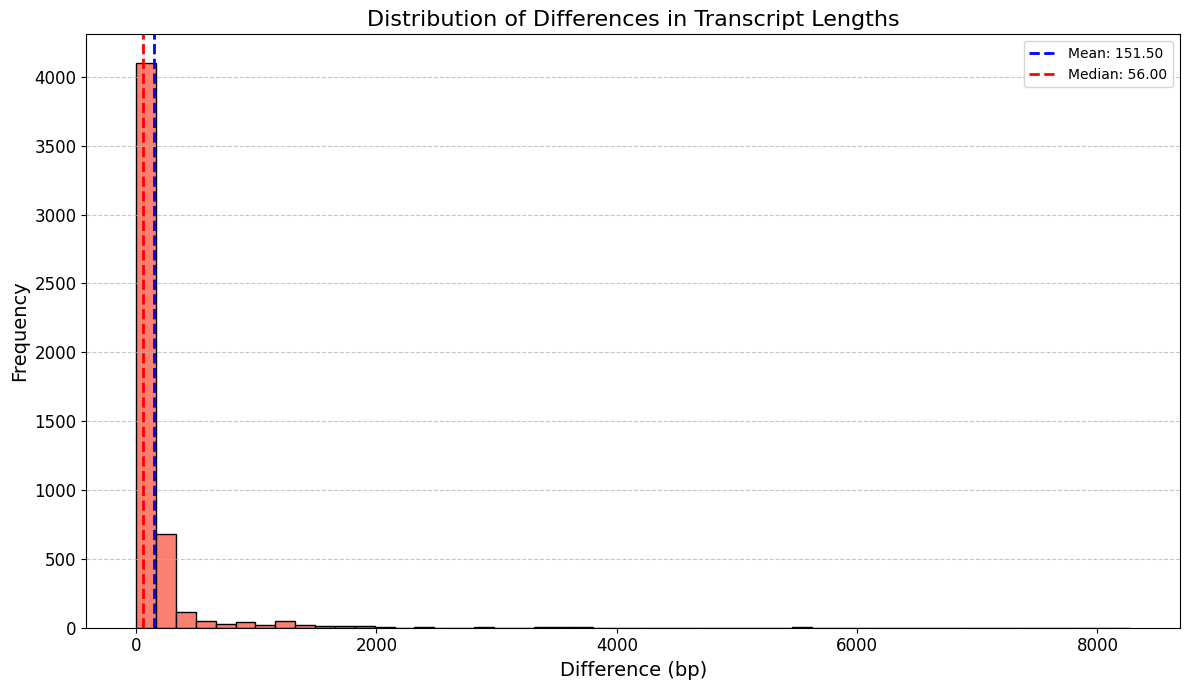

Number of unique genes: 6713
Unique gene IDs saved to: /home/saif/Documents/Saif_project_Yeast/scripts/outputs_of_scripts/genes_count_gff/unique_genes.csv


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv"
df = pd.read_csv(file_path)

# Count the number of unique genes
unique_gene_count = df['gene_id'].nunique()
print(f"Number of unique genes: {unique_gene_count}")

# Make all differences positive
differences = df['length_difference'].abs()

# Calculate statistics
mean_diff = differences.mean()
median_diff = differences.median()

# Create distribution plot
plt.figure(figsize=(12, 7))
plt.hist(differences, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Differences in Transcript Lengths', fontsize=16)
plt.xlabel('Difference (bp)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical lines for mean and median
plt.axvline(mean_diff, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='red', linestyle='--', linewidth=2, label=f'Median: {median_diff:.2f}')

plt.legend()
plt.tight_layout()
plt.show()



## the unique genes in original gff file 

import pandas as pd
import re
import os

# Load the GFF file
file_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
df = pd.read_csv(file_path, sep='\t', comment='#', header=None)

# Extract the attribute column (usually column 9 in GFF, index 8 in pandas)
attributes = df[8]

# Use regex to extract gene_id values from the attributes
gene_ids = attributes.str.extract(r'gene_id=([^;]+)')[0]

# Drop missing values and count unique gene IDs
unique_gene_ids = gene_ids.dropna().unique()
unique_gene_count = len(unique_gene_ids)

print(f"Number of unique genes: {unique_gene_count}")

# Define the target folder and ensure it exists
output_folder = "/home/saif/Documents/Saif_project_Yeast/scripts/outputs_of_scripts/genes_count_gff"  
os.makedirs(output_folder, exist_ok=True)

# Save unique gene IDs to CSV in that folder
output_csv = os.path.join(output_folder, "unique_genes.csv")
unique_genes_df = pd.DataFrame(unique_gene_ids, columns=["gene_id"])
unique_genes_df.to_csv(output_csv, index=False)

print(f"Unique gene IDs saved to: {output_csv}")


Not all of the original transcripts contain practices, which have been removed. Upon reviewing several genes, such as YBR158, it appears that there are significant size differences. This discrepancy is likely due to the peaks falling outside the range of the original transcripts.

## trim30

In [29]:
%%bash
## peak controller. MASC2

source /home/saif/anaconda3/bin/activate MASC2


macs2 callpeak \
-t /home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam \
--outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs/ \
-n last30 \
--nomodel \
--extsize 30

INFO  @ Wed, 30 Apr 2025 12:41:52: 
# Command line: callpeak -t /home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam --outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs/ -n last30 --nomodel --extsize 30
# ARGUMENTS LIST:
# name = last30
# format = AUTO
# ChIP-seq file = ['/home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
 
INFO  @ Wed, 30 Apr 2025 12:41:52: #1 read tag files... 
INFO  @ Wed, 30 Apr 2025 12:41:52: #1 read treatment tags... 
INFO  @ W

#### -n last30

Specifies the name prefix for all output files. 

#### --nomodel

Tells MACS2 not to build a model based on fragment size estimation from the data.

#### --extsize 30

Sets the fragment extension size to 30 bp.

## creating annotation file for new transcripts trim30_longest_annotation.gtf

In [18]:

import pandas as pd
import gffutils
import os

# === File paths ===
GFF_FILE = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
NARROWPEAK_FILE = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/last30_peaks.narrowPeak"
DB_FILE = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30.db"
OUTPUT_GTF = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30.gtf"

# === Load .narrowPeak and compute summit position ===
narrow_df = pd.read_csv(NARROWPEAK_FILE, sep='\t', header=None,
                        names=["chrom", "start", "end", "name", "score", "strand",
                               "signalValue", "pValue", "qValue", "peak"])

# Calculate summit position
narrow_df["summit_pos"] = narrow_df["start"] + narrow_df["peak"]
print(f"Total peaks loaded: {len(narrow_df)}")

# === Build or load GFF database ===
if not os.path.exists(DB_FILE):
    print("Creating GFF database...")
    gffutils.create_db(GFF_FILE, DB_FILE, merge_strategy="merge", keep_order=True)
db = gffutils.FeatureDB(DB_FILE)

# === Match summit positions to transcripts and build new entries ===
new_gtf_lines = []
seen = set()

for _, row in narrow_df.iterrows():
    chrom = row["chrom"]
    summit = int(row["summit_pos"])
    peak_name = row["name"]

    # Only get features where summit lies within transcript
    overlapping = db.region(region=(chrom, summit, summit + 1), completely_within=False)

    for feature in overlapping:
        if feature.featuretype not in ["mRNA", "transcript"]:
            continue

        if not (feature.start <= summit <= feature.end):
            continue

        gene_id = feature.attributes.get("gene_id", [None])[0] or feature.id
        strand = feature.strand

        if strand == "+":
            tx_start = feature.start
            tx_end = summit
        elif strand == "-":
            tx_start = summit
            tx_end = feature.end
        else:
            continue

        new_tx_id = f"{gene_id}_{peak_name}"
        if new_tx_id in seen:
            continue
        seen.add(new_tx_id)

        line = (
            f"{chrom}\tcustom\ttranscript\t{tx_start}\t{tx_end}\t.\t{strand}\t.\t"
            f'gene_id "{gene_id}"; transcript_id "{new_tx_id}";\n'
        )
        new_gtf_lines.append(line)

# === Write updated GTF ===
with open(OUTPUT_GTF, "w") as f:
    f.writelines(new_gtf_lines)

print(f"✅ Updated transcript annotations saved to {OUTPUT_GTF}")

Total peaks loaded: 8418
Creating GFF database...
✅ Updated transcript annotations saved to /home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30.gtf


### longest

In [19]:

import pandas as pd

def parse_gtf(file_path):
    entries = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split('\t')
            if len(parts) != 9 or parts[2] != "transcript":
                continue
            seq_id, source, feature_type, start, end, score, strand, phase, attributes = parts
            attr_dict = {}
            for attr in attributes.strip().split(';'):
                if ' ' in attr:
                    key, value = attr.strip().split(' ', 1)
                    attr_dict[key.strip()] = value.strip().strip('"')
            transcript_id = attr_dict.get('transcript_id', '')
            gene_id = attr_dict.get('gene_id', transcript_id.split('_')[0])
            entries.append({
                "line": line.strip(),
                "seq_id": seq_id,
                "start": int(start),
                "end": int(end),
                "length": int(end) - int(start),
                
                "strand": strand,
                "transcript_id": transcript_id,
                "gene_id": gene_id
            })
    return pd.DataFrame(entries)

# Paths
input_gtf = "//home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30.gtf"
output_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_longest_annotation.gtf"

# Parse the GTF
df = parse_gtf(input_gtf)

# Keep only the longest transcript per gene
longest_per_gene = df.sort_values(by="length", ascending=False).drop_duplicates(subset="gene_id")

# Write output
with open(output_gtf, "w") as f:
    for line in longest_per_gene['line']:
        f.write(line + "\n")

print(f"✅ Longest transcript per gene saved to: {output_gtf}")

✅ Longest transcript per gene saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_longest_annotation.gtf


## transcript_length --> trim30_longest_annotation.gtf

In [37]:
from collections import defaultdict
import pandas as pd

# path to file
gtf_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_longest_annotation.gtf"

transcript_lengths = defaultdict(int)

# Parse GTF file
with open(gtf_file, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        try:
            start = int(parts[3])
            end = int(parts[4])
            length = end - start + 1
            attributes = parts[8]
            if 'transcript_id "' in attributes:
                tid = attributes.split('transcript_id "')[1].split('"')[0]
                transcript_lengths[tid] += length
        except:
            continue

# Set your output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_transcript_length_comparison.csv"

# Create DataFrame and save
df = pd.DataFrame([
    {"transcript_id": tid, "length": length}
    for tid, length in transcript_lengths.items()
])

df.to_csv(output_path, index=False)
print(f"✅ Saved to: {output_path}")


✅ Saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_transcript_length_comparison.csv


## final_gene_length_differences

In [38]:
import pandas as pd

# Input paths
gtf_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_transcript_length_comparison.csv"
gff_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv"

# Output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences.csv"

# Load both datasets
gtf_df = pd.read_csv(gtf_csv_path)
gff_df = pd.read_csv(gff_csv_path)

# Extract gene_id by splitting on underscores
gtf_df['gene_id'] = gtf_df['transcript_id'].apply(lambda x: x.split('_')[0])
gff_df['gene_id'] = gff_df['transcript_id'].apply(lambda x: x.split('_')[0])

# Group by gene_id and sum lengths
gtf_lengths = gtf_df.groupby('gene_id')['length'].sum().reset_index(name='gtf_length')
gff_lengths = gff_df.groupby('gene_id')['length'].sum().reset_index(name='gff_length')

# Merge and compute length difference
merged_df = pd.merge(gtf_lengths, gff_lengths, on='gene_id', how='outer').fillna(0)
merged_df['length_difference'] = merged_df['gtf_length'] - merged_df['gff_length']

# Save the result
merged_df.to_csv(output_path, index=False)
print(f"✅ Gene-wise length comparison saved to: {output_path}")


✅ Gene-wise length comparison saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences.csv


## trim30_final_gene_length_differences_gtf_filtered.csv

In [25]:

import pandas as pd

# Set the input and output paths
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv"

# Load the CSV file
df = pd.read_csv(input_path)

# Filter out rows where gtf_length is 0
df_filtered = df[df['gtf_length'] != 0]

# Save the cleaned DataFrame
df_filtered.to_csv(output_path, index=False)

print(f"✅ Filtered data saved to: {output_path}")



✅ Filtered data saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv


Number of unique genes: 5824


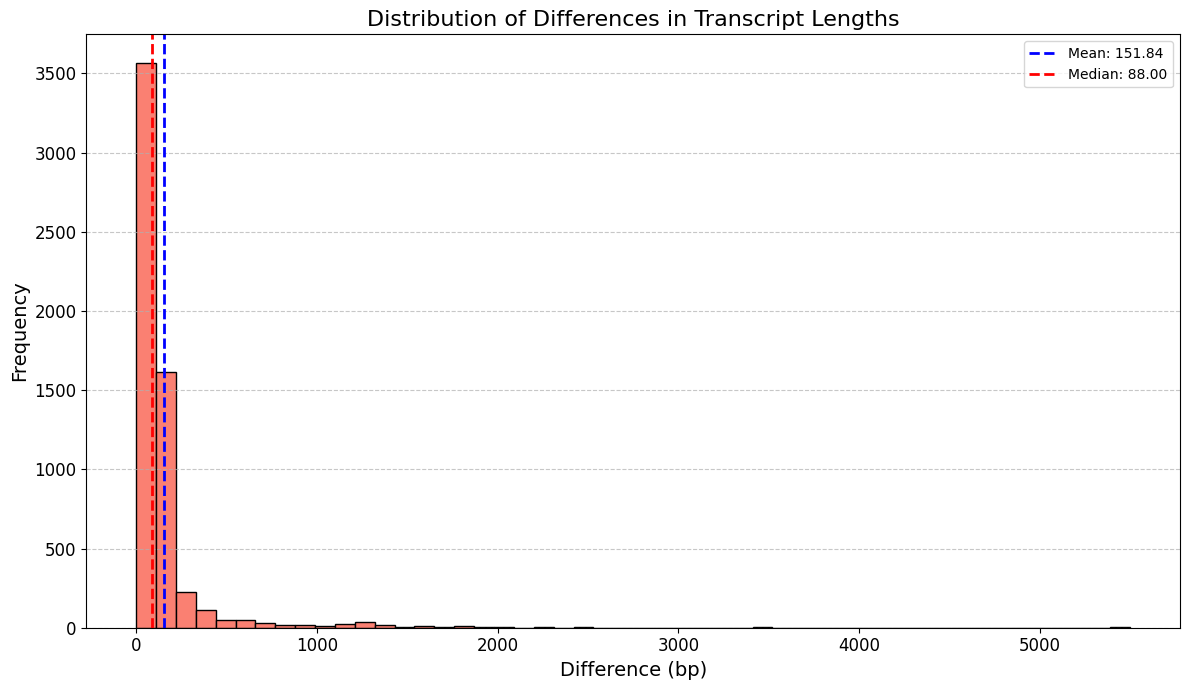

Number of unique genes: 6713
Unique gene IDs saved to: /home/saif/Documents/Saif_project_Yeast/scripts/outputs_of_scripts/genes_count_gff/unique_genes.csv


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv"
df = pd.read_csv(file_path)

# Count the number of unique genes
unique_gene_count = df['gene_id'].nunique()
print(f"Number of unique genes: {unique_gene_count}")

# Make all differences positive
differences = df['length_difference'].abs()

# Calculate statistics
mean_diff = differences.mean()
median_diff = differences.median()

# Create distribution plot
plt.figure(figsize=(12, 7))
plt.hist(differences, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Differences in Transcript Lengths', fontsize=16)
plt.xlabel('Difference (bp)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical lines for mean and median
plt.axvline(mean_diff, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='red', linestyle='--', linewidth=2, label=f'Median: {median_diff:.2f}')

plt.legend()
plt.tight_layout()
plt.show()



## the unique genes in original gff file 

import pandas as pd
import re
import os

# Load the GFF file
file_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
df = pd.read_csv(file_path, sep='\t', comment='#', header=None)

# Extract the attribute column (usually column 9 in GFF, index 8 in pandas)
attributes = df[8]

# Use regex to extract gene_id values from the attributes
gene_ids = attributes.str.extract(r'gene_id=([^;]+)')[0]

# Drop missing values and count unique gene IDs
unique_gene_ids = gene_ids.dropna().unique()
unique_gene_count = len(unique_gene_ids)

print(f"Number of unique genes: {unique_gene_count}")

# Define the target folder and ensure it exists
output_folder = "/home/saif/Documents/Saif_project_Yeast/scripts/outputs_of_scripts/genes_count_gff"  
os.makedirs(output_folder, exist_ok=True)

# Save unique gene IDs to CSV in that folder
output_csv = os.path.join(output_folder, "unique_genes.csv")
unique_genes_df = pd.DataFrame(unique_gene_ids, columns=["gene_id"])
unique_genes_df.to_csv(output_csv, index=False)

print(f"Unique gene IDs saved to: {output_csv}")


# last30_2

In [30]:
%%bash
## peak controller. MASC2

source /home/saif/anaconda3/bin/activate MASC2

macs2 callpeak \
-t /home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam \
--outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs/ \
-n last30_2 \
--nomodel \
--extsize 30 \
--keep-dup auto \
-B --SPMR

INFO  @ Wed, 30 Apr 2025 12:43:05: 
# Command line: callpeak -t /home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam --outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs/ -n last30_2 --nomodel --extsize 30 --keep-dup auto -B --SPMR
# ARGUMENTS LIST:
# name = last30_2
# format = AUTO
# ChIP-seq file = ['/home/saif/Documents/Saif_project_Yeast/pysam/output_reverseCorrected_last30_sorted.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
# MACS will save fragment pileup signal per million reads
 
INFO  @ Wed, 30 Apr 2025 12:43:05: #1 re

## creating annotation file for new transcripts trim30_annotation.gtf

In [31]:

import pandas as pd
import gffutils
import os

# === File paths ===
GFF_FILE = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
NARROWPEAK_FILE = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/last30_2_peaks.narrowPeak"
DB_FILE = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30_2.db"
OUTPUT_GTF = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30_2.gtf"

# === Load .narrowPeak and compute summit position ===
narrow_df = pd.read_csv(NARROWPEAK_FILE, sep='\t', header=None,
                        names=["chrom", "start", "end", "name", "score", "strand",
                               "signalValue", "pValue", "qValue", "peak"])

# Calculate summit position
narrow_df["summit_pos"] = narrow_df["start"] + narrow_df["peak"]
print(f"Total peaks loaded: {len(narrow_df)}")

# === Build or load GFF database ===
if not os.path.exists(DB_FILE):
    print("Creating GFF database...")
    gffutils.create_db(GFF_FILE, DB_FILE, merge_strategy="merge", keep_order=True)
db = gffutils.FeatureDB(DB_FILE)

# === Match summit positions to transcripts and build new entries ===
new_gtf_lines = []
seen = set()

for _, row in narrow_df.iterrows():
    chrom = row["chrom"]
    summit = int(row["summit_pos"])
    peak_name = row["name"]

    # Only get features where summit lies within transcript
    overlapping = db.region(region=(chrom, summit, summit + 1), completely_within=False)

    for feature in overlapping:
        if feature.featuretype not in ["mRNA", "transcript"]:
            continue

        if not (feature.start <= summit <= feature.end):
            continue

        gene_id = feature.attributes.get("gene_id", [None])[0] or feature.id
        strand = feature.strand

        if strand == "+":
            tx_start = feature.start
            tx_end = summit
        elif strand == "-":
            tx_start = summit
            tx_end = feature.end
        else:
            continue

        new_tx_id = f"{gene_id}_{peak_name}"
        if new_tx_id in seen:
            continue
        seen.add(new_tx_id)

        line = (
            f"{chrom}\tcustom\ttranscript\t{tx_start}\t{tx_end}\t.\t{strand}\t.\t"
            f'gene_id "{gene_id}"; transcript_id "{new_tx_id}";\n'
        )
        new_gtf_lines.append(line)

# === Write updated GTF ===
with open(OUTPUT_GTF, "w") as f:
    f.writelines(new_gtf_lines)

print(f"✅ Updated transcript annotations saved to {OUTPUT_GTF}")

Total peaks loaded: 8401
Creating GFF database...
✅ Updated transcript annotations saved to /home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30_2.gtf


## longest

In [32]:

import pandas as pd

def parse_gtf(file_path):
    entries = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split('\t')
            if len(parts) != 9 or parts[2] != "transcript":
                continue
            seq_id, source, feature_type, start, end, score, strand, phase, attributes = parts
            attr_dict = {}
            for attr in attributes.strip().split(';'):
                if ' ' in attr:
                    key, value = attr.strip().split(' ', 1)
                    attr_dict[key.strip()] = value.strip().strip('"')
            transcript_id = attr_dict.get('transcript_id', '')
            gene_id = attr_dict.get('gene_id', transcript_id.split('_')[0])
            entries.append({
                "line": line.strip(),
                "seq_id": seq_id,
                "start": int(start),
                "end": int(end),
                "length": int(end) - int(start),
                
                "strand": strand,
                "transcript_id": transcript_id,
                "gene_id": gene_id
            })
    return pd.DataFrame(entries)

# Paths
input_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/narrowpeak_transcripts_trim30_2.gtf"
output_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_2_longest_annotation.gtf"

# Parse the GTF
df = parse_gtf(input_gtf)

# Keep only the longest transcript per gene
longest_per_gene = df.sort_values(by="length", ascending=False).drop_duplicates(subset="gene_id")

# Write output
with open(output_gtf, "w") as f:
    for line in longest_per_gene['line']:
        f.write(line + "\n")

print(f"✅ Longest transcript per gene saved to: {output_gtf}")

✅ Longest transcript per gene saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_2_longest_annotation.gtf


## transcript_length --> trim30_2_longest_annotation.gtf

In [36]:
from collections import defaultdict
import pandas as pd

# path to file
gtf_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/new_annotation/trim30_2_longest_annotation.gtf"

transcript_lengths = defaultdict(int)

# Parse GTF file
with open(gtf_file, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        try:
            start = int(parts[3])
            end = int(parts[4])
            length = end - start + 1
            attributes = parts[8]
            if 'transcript_id "' in attributes:
                tid = attributes.split('transcript_id "')[1].split('"')[0]
                transcript_lengths[tid] += length
        except:
            continue

# Set your output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_transcript_length_comparison.csv"

# Create DataFrame and save
df = pd.DataFrame([
    {"transcript_id": tid, "length": length}
    for tid, length in transcript_lengths.items()
])

df.to_csv(output_path, index=False)
print(f"✅ Saved to: {output_path}")


✅ Saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_transcript_length_comparison.csv


## final_gene_length_differences

In [39]:
import pandas as pd

# Input paths
gtf_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_transcript_length_comparison.csv"
gff_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv"

# Output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences.csv"

# Load both datasets
gtf_df = pd.read_csv(gtf_csv_path)
gff_df = pd.read_csv(gff_csv_path)

# Extract gene_id by splitting on underscores
gtf_df['gene_id'] = gtf_df['transcript_id'].apply(lambda x: x.split('_')[0])
gff_df['gene_id'] = gff_df['transcript_id'].apply(lambda x: x.split('_')[0])

# Group by gene_id and sum lengths
gtf_lengths = gtf_df.groupby('gene_id')['length'].sum().reset_index(name='gtf_length')
gff_lengths = gff_df.groupby('gene_id')['length'].sum().reset_index(name='gff_length')

# Merge and compute length difference
merged_df = pd.merge(gtf_lengths, gff_lengths, on='gene_id', how='outer').fillna(0)
merged_df['length_difference'] = merged_df['gtf_length'] - merged_df['gff_length']

# Save the result
merged_df.to_csv(output_path, index=False)
print(f"✅ Gene-wise length comparison saved to: {output_path}")


✅ Gene-wise length comparison saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences.csv


## trim30_final_gene_length_differences_gtf_filtered.csv

In [40]:

import pandas as pd

# Set the input and output paths
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv"

# Load the CSV file
df = pd.read_csv(input_path)

# Filter out rows where gtf_length is 0
df_filtered = df[df['gtf_length'] != 0]

# Save the cleaned DataFrame
df_filtered.to_csv(output_path, index=False)

print(f"✅ Filtered data saved to: {output_path}")



✅ Filtered data saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv


Number of unique genes: 5831


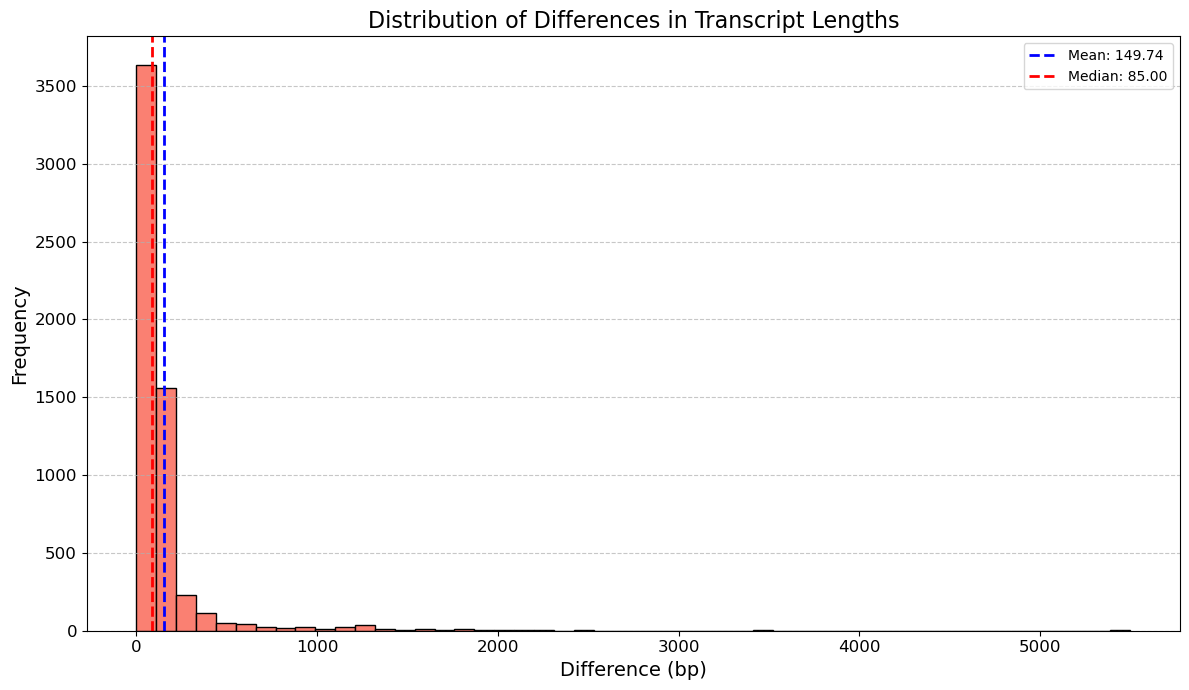

Number of unique genes: 6713
Unique gene IDs saved to: /home/saif/Documents/Saif_project_Yeast/scripts/outputs_of_scripts/trim30_2_genes_count_gff/unique_genes.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv"
df = pd.read_csv(file_path)

# Count the number of unique genes
unique_gene_count = df['gene_id'].nunique()
print(f"Number of unique genes: {unique_gene_count}")

# Make all differences positive
differences = df['length_difference'].abs()

# Calculate statistics
mean_diff = differences.mean()
median_diff = differences.median()

# Create distribution plot
plt.figure(figsize=(12, 7))
plt.hist(differences, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Differences in Transcript Lengths', fontsize=16)
plt.xlabel('Difference (bp)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical lines for mean and median
plt.axvline(mean_diff, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='red', linestyle='--', linewidth=2, label=f'Median: {median_diff:.2f}')

plt.legend()
plt.tight_layout()
plt.show()



## the unique genes in original gff file 

import pandas as pd
import re
import os

# Load the GFF file
file_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
df = pd.read_csv(file_path, sep='\t', comment='#', header=None)

# Extract the attribute column (usually column 9 in GFF, index 8 in pandas)
attributes = df[8]

# Use regex to extract gene_id values from the attributes
gene_ids = attributes.str.extract(r'gene_id=([^;]+)')[0]

# Drop missing values and count unique gene IDs
unique_gene_ids = gene_ids.dropna().unique()
unique_gene_count = len(unique_gene_ids)

print(f"Number of unique genes: {unique_gene_count}")

# 
output_folder = "/home/saif/Documents/Saif_project_Yeast/scripts/outputs_of_scripts/trim30_2_genes_count_gff"  
os.makedirs(output_folder, exist_ok=True)

# Save unique gene IDs to CSV in that folder
output_csv = os.path.join(output_folder, "unique_genes.csv")
unique_genes_df = pd.DataFrame(unique_gene_ids, columns=["gene_id"])
unique_genes_df.to_csv(output_csv, index=False)

print(f"Unique gene IDs saved to: {output_csv}")


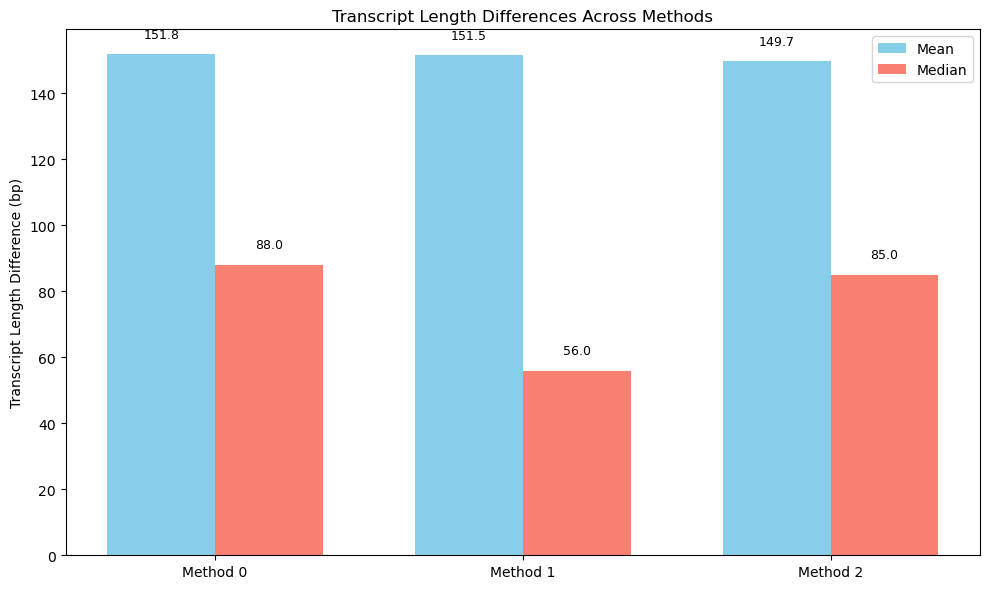

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths for 3 methods
paths = {
    "Method 0": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv",
    "Method 1": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv",
    "Method 2": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv"
}

# Collect summary
summary_data = []
for method, path in paths.items():
    df = pd.read_csv(path)
    diffs = df["length_difference"].abs()
    summary_data.append({
        "Method": method,
        "Mean": diffs.mean(),
        "Median": diffs.median(),
        "Unique Genes": df["gene_id"].nunique()
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Plot mean/median differences
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(summary_df))
width = 0.35

ax.bar([i - width/2 for i in x], summary_df["Mean"], width, label="Mean", color="skyblue")
ax.bar([i + width/2 for i in x], summary_df["Median"], width, label="Median", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(summary_df["Method"])
ax.set_ylabel("Transcript Length Difference (bp)")
ax.set_title("Transcript Length Differences Across Methods")
ax.legend()

# Add labels
for i, row in summary_df.iterrows():
    ax.text(i - width/2, row["Mean"] + 5, f"{row['Mean']:.1f}", ha="center", fontsize=9)
    ax.text(i + width/2, row["Median"] + 5, f"{row['Median']:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


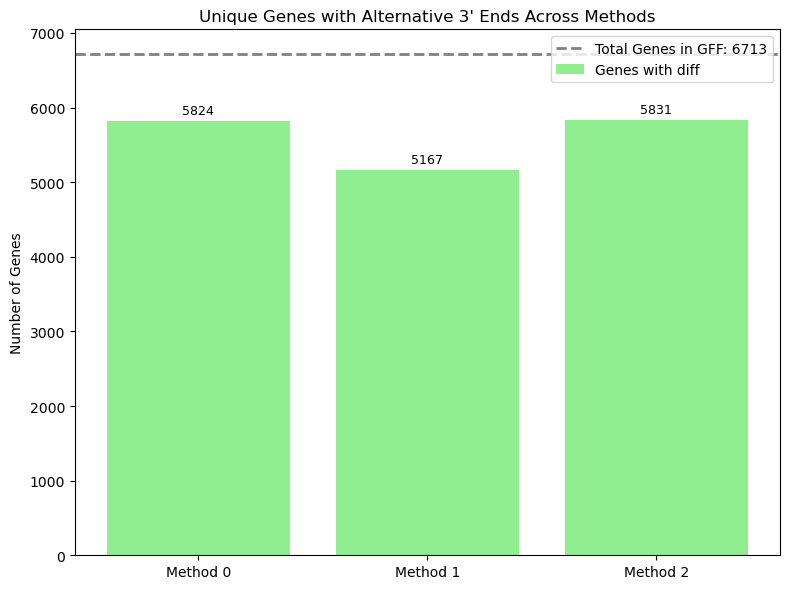

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Corrected total number of genes in GFF
reference_gene_count = 6713

# Paths for 3 methods
paths = {
    "Method 0": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv",
    "Method 1": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv",
    "Method 2": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv"
}

# Collect summary
summary_data = []
for method, path in paths.items():
    df = pd.read_csv(path)
    diffs = df["length_difference"].abs()
    summary_data.append({
        "Method": method,
        "Mean": diffs.mean(),
        "Median": diffs.median(),
        "Unique Genes": df["gene_id"].nunique()
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# === Bar plot of number of unique genes vs reference ===
fig, ax = plt.subplots(figsize=(8, 6))
x = range(len(summary_df))
bars = ax.bar(summary_df["Method"], summary_df["Unique Genes"], color="lightgreen", label="Genes with diff")

# Add horizontal reference line
ax.axhline(reference_gene_count, color='gray', linestyle='--', linewidth=2,
           label=f"Total Genes in GFF: {reference_gene_count}")

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 50, f"{int(height)}",
            ha='center', va='bottom', fontsize=9)

# Final plot styling
ax.set_ylabel("Number of Genes")
ax.set_title("Unique Genes with Alternative 3' Ends Across Methods")
ax.legend()
plt.tight_layout()
plt.show()
